# 04 Beyond Reddit: external attention signals (Phase 5)
Working notebook. So far only YouTube trending (C33). Google Trends and TikTok are not done; the news-vs-brainrot and news-vs-TikTok Trends comparisons were dropped because the series are not comparable in size (news averages about 48 on the 0-100 scale, TikTok about 5). Not part of `eda.ipynb`.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import pandas as pd
from src.viz import set_style, GROUP_COLORS, SUB_COLORS, ACCENT, GRAY, save, finding_title, caption, event_line, highlight_vs_gray
from src.config import AGG, EXT, EVENTS, GROUPS
set_style()

## Data and limits
Two public Kaggle datasets of YouTube's daily trending lists, downloaded one file at a time (the whole-archive download of the first one is broken on Kaggle; see `docs/research_log.md`):
- **rsrishav/youtube-trending-video-dataset**: US, GB, CA and IN, trending dates 12 Aug 2020 to 15 Apr 2024, up to 200 videos a day per country.
- **keshavbansal95/youtube-trending-videos-dataset**: about 80 countries, trending dates 12 Oct 2024 to 26 Sep 2025.

Each video counts once (the same video trends in dozens of countries). A video is "brainrot-titled" when its title or tags match the brainrot lexicon (brain rot, skibidi, rizz, gyatt, fanum tax, mewing, tralalero, tung tung). One 2025 Roblox game, "Steal a Brainrot", is flagged separately. The two lists are built differently and there is a gap from mid-April to mid-October 2024, so shares are compared within a list only. Views are the values recorded when a video was listed, not age-normalized. Months with fewer than 1,000 trending videos are dropped.

### Q33. Do brainrot titles reach YouTube's trending lists, and has that changed? (H2)
**Why we asked:** Reddit shows how people talk; YouTube trending shows what mainstream audiences are shown. If brainrot is a short-form media phenomenon it should reach the lists.

**What we did:** Brainrot-titled videos per 1,000 trending videos by publish month for each list (with and without the Roblox game), and the median views of those videos with the number of videos as marker size, since a median of three videos means little.

**Result:** In the 2020-24 list (US, GB, CA, IN) the share is about 0.2 per 1,000 until May 2023, peaks at 9.9 in July 2023 (35 of 3,535 videos) and falls to 3.0 in the last quarter of 2023 and 1.3 in the first of 2024. In the 2024-25 list (about 80 countries) it is 0 to 5 per 1,000 from October 2024 to March 2025, 6 to 8 in April to June 2025, then 42 in July, 66 in August and 67 in September 2025; without the game these are 25, 31 and 27. Median views of brainrot-titled videos are 0.5-1.6M in 2023, 1-8M from October 2024 to June 2025 (1 to 17 videos a month) and fall to 0.17-0.23M in July to September 2025 (194 to 590 videos a month).

**Interpretation:** Brainrot reached the trending lists twice: a first small wave in mid-2023, which matches the Reddit slang peak (Q15), and a much larger one in summer 2025, about half of it one Roblox game. The 2025 wave is broad, not big: many more videos, each with far fewer views, which fits the long tail of small creators and smaller countries in that list. We cannot say how much of the jump is the lists themselves (the 2025 file has four times more videos in the last quarter) rather than the topic; that is why only per-1,000 shares are shown. Titles and tags show use of the word, not the content style.

**Next question:** Do search interest (Google Trends) and TikTok itself show the same two waves?

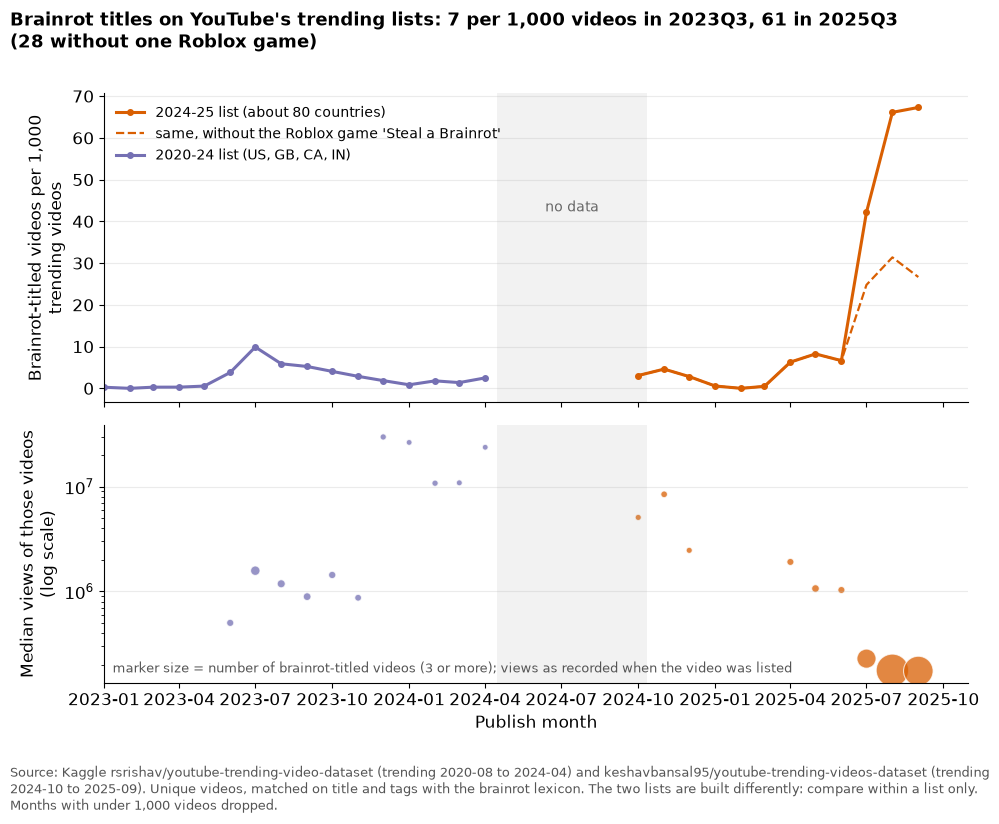

In [2]:
from src import figs_external as figs
_ = figs.c33()
plt.show()

**Code for C33:** `src/figs_external.py` function `c33()`; reads `youtube_trending_monthly`; built by `python run_pipeline.py external`. All charts and tables: `docs/figure_index.md`, scripts explained in `docs/code_guide.md`.